C:\Users\vivek\anaconda4\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\vivek\anaconda4\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.6708 - mae: 0.8694 - mse: 1.6708 - val_loss: 0.4696 - val_mae: 0.4958 - val_mse: 0.4696
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4079 - mae: 0.4557 - mse: 0.4079 - val_loss: 0.4184 - val_mae: 0.4501 - val_mse: 0.4184
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3663 - mae: 0.4342 - mse: 0.3663 - val_loss: 0.3991 - val_mae: 0.4524 - val_mse: 0.3991
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3606 - mae: 0.4275 - mse: 0.3606 - val_loss: 0.3882 - val_mae: 0.4503 - val_mse: 0.3882
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3943 - mae: 0.4250 - mse: 0.3943 - val_loss: 0.3650 - val_mae: 0.4231 - val_mse: 0.3650
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3300 - mae: 0.4062 - mse: 0.3300 - val_loss: 0.3484 - val_mae: 0.4089 - val_mse: 0.3484
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3062 - mae: 0.3881 - mse: 0.3062 - val

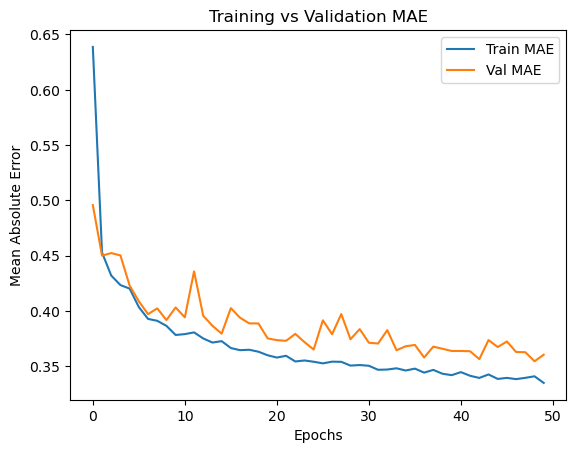

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2700 - mae: 0.3533 - mse: 0.2700

Evaluation Metrics on Test Set:
MAE: 0.36
MSE: 0.28
RMSE: 0.53
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
R² Score: 0.79


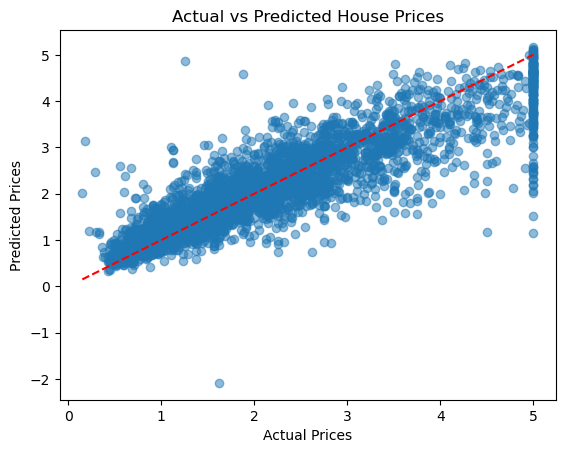

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

housing = fetch_california_housing(as_frame=True)
df = housing.frame

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=[X_train.shape[1]]),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)  # Output layer for regression
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', 'mse']
)


history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.title('Training vs Validation MAE')
plt.legend()
plt.show()

test_loss, test_mae, test_mse = model.evaluate(X_test_scaled, y_test)
test_rmse = np.sqrt(test_mse)
print(f"\nEvaluation Metrics on Test Set:")
print(f"MAE: {test_mae:.2f}")
print(f"MSE: {test_mse:.2f}")
print(f"RMSE: {test_rmse:.2f}")


y_pred = model.predict(X_test_scaled).flatten()
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.2f}")


plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.show()


In [2]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
